# Introduction to Reinforcement Learning

Taken from Starmer (2025)

### The Scenario
Imagine you are driving down a highway and you see two identical fast-food options: **Burger King A** and **Burger King B**. You want to grab a quick bite, but you don't know which one tends to serve massive meals and which one serves smaller, snack-sized portions.

We will use a neural network with **Policy Gradients** to learn the best strategy (policy) based on your current **Hunger Level**.

---

### Step 1: The State (Input)
We start by checking your current state, which is your **Hunger Level**.
Let's say your Hunger Level is **0.0**, meaning you are not really hungry at all; you just want a tiny snack. We feed this value of 0.0 into our neural network.

### Step 2: The Policy (The Probabilities)
The neural network multiplies your Hunger Level by a weight and adds a bias, then passes that result through a Sigmoid activation function.

Because the network hasn't learned anything yet, it outputs a 50/50 split:
*   The probability of going to **Burger King B** is **0.5** (50%).
*   The probability of going to **Burger King A** is $1 - 0.5 =$ **0.5** (50%).

### Step 3: The Action (The Guess)
The neural network gives you probabilities. To make a decision, the agent picks a random number between 0 and 1.
Let's say the random number dictates that we choose **Burger King A**.

### Step 4: The Environment & The Reward
You pull into the drive-thru at **Burger King A** and place your order.

**Scenario 1: A Good Guess (Positive Reward)**
Burger King A hands you a small portion of fries and a single slider. Because your Hunger Level was 0.0, a small snack is exactly what you needed
*   **The Reward:** Since this was the correct choice, the environment gives you a reward of **+1.0**.

**Scenario 2: A Bad Guess (Negative Reward)**
Imagine instead that you had chosen Burger King B. They hand you a gigantic combo. Because you weren't hungry, you can't eat it, and you've made a mistake.
*   **The Reward:** Since this was the wrong choice, the environment gives you a reward of **-1.0**.

### Step 5: The Policy Gradient Update (Learning)
First, the network calculates the **derivative of the Cross Entropy loss** based on the choice you made using the **Chain Rule**. This derivative tells the network how to adjust its internal *Bias* to increase the probability of taking that exact same action again.

*   **If you made the Good Guess (Burger King A):**

    The Cross Entropy for Burger King A is:
    $$CE_A = -\log(p(\text{Burger King A})) = -\log(1 - p(\text{Burger King B}))$$

    We use the Chain Rule to calculate the derivative of the Cross Entropy with respect to the Bias:
    $$\frac{\partial CE_A}{\partial Bias} = \frac{\partial CE_A}{\partial p(\text{Burger King B})} \times \frac{\partial p(\text{Burger King B})}{\partial x} \times \frac{\partial x}{\partial Bias}$$
    $$\frac{\partial CE_A}{\partial Bias} = \frac{1}{1 - p(\text{Burger King B})} \times p(\text{Burger King B})(1 - p(\text{Burger King B})) \times 1$$
    $$\frac{\partial CE_A}{\partial Bias} = p(\text{Burger King B}) = 0.5$$

    You multiply the derivative by your positive reward (**+1.0**). The derivative stays pointing in the same direction. When you update the network using Gradient Descent, it shifts the Bias so that the next time your Hunger Level is 0.0, the probability of going to Burger King A increases (e.g., to 60%).
    
    $$Updated\ Derivative = \frac{\partial CE_A}{\partial Bias} \times Reward = 0.5 \times 1.0 = 0.5$$

*   **If you made the Bad Guess (Burger King B):**

    The Cross Entropy for Burger King B is:
    $$CE_B = -\log(p(\text{Burger King B}))$$

    We use the Chain Rule to calculate the derivative of the Cross Entropy with respect to the Bias:
    $$\frac{\partial CE_B}{\partial Bias} = \frac{\partial CE_B}{\partial p(\text{Burger King B})} \times \frac{\partial p(\text{Burger King B})}{\partial x} \times \frac{\partial x}{\partial Bias}$$
    $$\frac{\partial CE_B}{\partial Bias} = \frac{-1}{p(\text{Burger King B})} \times p(\text{Burger King B})(1 - p(\text{Burger King B})) \times 1$$
    $$\frac{\partial CE_B}{\partial Bias} = -(1 - p(\text{Burger King B})) = -0.5$$

    You multiply the derivative by your negative reward (**-1.0**). *This is the magic of Policy Gradients!* Multiplying by a negative number flips the direction of the derivative. Now, when you update the network, it shifts the Bias in the *opposite* direction. The network corrects its mistake, ensuring that next time your Hunger Level is 0.0, the probability of going to Burger King B decreases (and consequently, the probability of going to Burger King A increases).
    
    $$Updated\ Derivative = \frac{\partial CE_B}{\partial Bias} \times Reward = -0.5 \times -1.0 = 0.5$$

**Calculating the Step Size and updating the Bias:**

$$Step\ Size = Learning\ Rate \times Updated\ Derivative$$
$$New\ Bias = Old\ Bias - Step\ Size$$

### The Result
By repeatedly taking these actions, getting rewards (or punishments), and multiplying the network's gradients by those rewards, the neural network eventually learns a perfect policy: always go to Burger King A when you want a small snack, and go to Burger King B when you are starving

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Bernoulli

# Step 2: The Policy (The Neural Network)
class SimpleRL(nn.Module):
    def __init__(self):
        super().__init__()
        # Input (Hunger Level) then Output (x = Hunger * Weight + Bias)
        self.fc = nn.Linear(in_features=1, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, hunger):
        x = self.fc(hunger)
        prob_B = self.sigmoid(x) # Output: Probability of choosing Burger King B
        return prob_B

# Initialize the model and the optimizer
model = SimpleRL()
optimizer = optim.SGD(model.parameters(), lr=1.0)

# Training Loop
for episode in range(10):
    optimizer.zero_grad() # Clear old gradients

    # Step 1: The State
    # Let's assume our hunger is 0.0
    hunger_level = torch.tensor([0.0])

    # Step 2: The Policy (Get Probabilities)
    prob_B = model(hunger_level)
    prob_A = 1.0 - prob_B

    # Step 3: The Action (The Guess)
    # We use a Bernoulli distribution to random choose
    dice_roll = Bernoulli(prob_B)
    action = dice_roll.sample()

    # Step 4: The Environment & The Reward
    if action == 0.0:
        print(f"Episode {episode+1}: Chose Burger King A. Good guess!")
        reward = 1.0
        prob_of_action_taken = prob_A # We track the probability of the action we ACTUALLY took
    else:
        print(f"Episode {episode+1}: Chose Burger King B. Bad guess!")
        reward = -1.0
        prob_of_action_taken = prob_B

    # Step 5: The Policy Gradient Update
    loss = -torch.log(prob_of_action_taken) * reward

    # Calculate the derivatives automatically
    loss.backward()

    # Update the Weight and Bias: New Bias = Old Bias - Step Size
    optimizer.step()

    print(f"   -> Negative Log Loss: {loss.item()}; New Probability of going to Burger King A: {(1.0 - model(hunger_level).item()) * 100:.2f}%\n")

Episode 1: Chose Burger King A. Good guess!
   -> Negative Log Loss: 0.33836573362350464; New Probability of going to Burger King A: 76.79%

Episode 2: Chose Burger King A. Good guess!
   -> Negative Log Loss: 0.2640368640422821; New Probability of going to Burger King A: 80.67%

Episode 3: Chose Burger King B. Bad guess!
   -> Negative Log Loss: -1.643585443496704; New Probability of going to Burger King A: 90.34%

Episode 4: Chose Burger King A. Good guess!
   -> Negative Log Loss: 0.10159691423177719; New Probability of going to Burger King A: 91.15%

Episode 5: Chose Burger King A. Good guess!
   -> Negative Log Loss: 0.09266089648008347; New Probability of going to Burger King A: 91.84%

Episode 6: Chose Burger King A. Good guess!
   -> Negative Log Loss: 0.08513744920492172; New Probability of going to Burger King A: 92.43%

Episode 7: Chose Burger King A. Good guess!
   -> Negative Log Loss: 0.07872062921524048; New Probability of going to Burger King A: 92.94%

Episode 8: Chose

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Bernoulli


# Step 1: The Policy Network
class SimpleRL(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(in_features=1, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, hunger):
        x = self.fc(hunger)
        prob_B = self.sigmoid(x) # Probability of choosing B (Big Meal)
        return prob_B

model = SimpleRL()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Training Loop
for episode in range(1000):
    optimizer.zero_grad()

    # 1. THE STATE: Generate a random hunger level between 0.0 and 1.0
    hunger_level = torch.rand(1)

    # 2. THE POLICY: Compute model probabilities based on the current hunger
    prob_B = model(hunger_level)
    prob_A = 1.0 - prob_B

    # 3. THE ACTION: random choice
    dice_roll = Bernoulli(prob_B)
    action = dice_roll.sample()

    # 4. THE ENVIRONMENT & REWARD LOGIC
    if hunger_level.item() < 0.5:
        # Agent is NOT very hungry
        if action == 0.0:  # Chose A (Snack)
            reward = 1.0   # Good guess
            prob_taken = prob_A
        else:              # Chose B (Big Meal)
            reward = -1.0  # Bad guess
            prob_taken = prob_B

    else:
        # Agent IS very hungry
        if action == 1.0:  # Chose B (Big Meal)
            reward = 1.0   # Good guess
            prob_taken = prob_B
        else:              # Chose A (Snack)
            reward = -1.0  # Bad guess
            prob_taken = prob_A

    # 5. THE POLICY GRADIENT UPDATE
    # Loss = -log(probability of action taken) * reward
    loss = -torch.log(prob_taken) * reward

    if episode % 100==0:
        print([p.item() for p in model.parameters()])

    loss.backward()
    optimizer.step()


# Testing
print("Testing")

# Test 1: Not hungry at all (Hunger = 0.1)
test_hunger_low = torch.tensor([0.1])
prob_B_low = model(test_hunger_low).item()
print(f"Hunger: 0.1 -> Probability of going to A (Snack): {(1.0 - prob_B_low)*100:.1f}%")

# Test 2: Starving (Hunger = 0.9)
test_hunger_high = torch.tensor([0.9])
prob_B_high = model(test_hunger_high).item()
print(f"Hunger: 0.9 -> Probability of going to B (Big Meal): {prob_B_high*100:.1f}%")

[-0.029189348220825195, 0.5107272863388062]
[0.7850527763366699, 0.11107327044010162]
[1.816007375717163, -0.2178451269865036]
[2.509650468826294, -0.8756481409072876]
[3.2385661602020264, -1.5252563953399658]
[4.001282691955566, -1.7377575635910034]
[4.412257671356201, -2.4086618423461914]
[4.976521015167236, -2.5098562240600586]
[5.621391296386719, -2.394787073135376]
[5.983382701873779, -2.6836516857147217]
Testing
Hunger: 0.1 -> Probability of going to A (Snack): 90.9%
Hunger: 0.9 -> Probability of going to B (Big Meal): 94.6%


## Overfitting problems

In traditional Machine Learning, overfitting happens when a model memorizes the training data instead of learning the underlying patterns.

In Reinforcement Learning (RL), overfitting looks a bit different but is just as dangerous. Instead of memorizing a dataset, an RL agent can "overfit" to a specific sequence of actions or get stuck in a rut where it completely stops exploring.

### Overfitting in our Toy Example
In our simple "Burger King" script, the network only has one weight and one bias, so it’s too small to truly overfit. But imagine if we used a massive neural network with 100 layers just to solve this hunger problem.

If the agent gets lucky a few times early on by choosing Burger King B when hunger is 0.51, the network might rapidly push the probability of choosing Burger King B to **99.99%**.
* Because the probability is 99.99%, it will almost *never* choose Burger King A again.
* If it never chooses A, it can never learn if A was actually the better choice for certain hunger levels.
* The agent becomes overconfident and blindly exploits its early (and possibly flawed) discoveries without exploring anymore.

### How to fix it in RL: The Entropy Bonus
The most common and powerful way to prevent overfitting in Policy Gradients is by adding an **Entropy Bonus** to the loss function.

In information theory, **Entropy** is a measure of randomness or uncertainty.
* A 50/50 probability has **High Entropy** (very uncertain).
* A 99/1 probability has **Low Entropy** (very certain).

To stop the neural network from becoming too certain too quickly, we **reward the network for having high entropy**. We do this by subtracting the entropy from our loss (since optimizers try to make the loss as small as possible, subtracting a value encourages the network to make that value larger).

### The Updated PyTorch Code (with Entropy Bonus)
PyTorch makes adding an entropy bonus incredibly easy because the `Bernoulli` distribution object actually has a built-in `.entropy()` function!

Here is how you add it to the training loop:

```python
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Bernoulli

class simpleRL(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(in_features=1, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, hunger):
        return self.sigmoid(self.fc(hunger))

model = simpleRL()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Entropy weight (beta).
# A higher beta forces the agent to explore more. A lower beta lets it exploit.
beta = 0.05

for episode in range(1000):
    optimizer.zero_grad()
    
    hunger_level = torch.rand(1)
    
    prob_B = model(hunger_level)
    prob_A = 1.0 - prob_B
    
    # "Roll the dice"
    dice_roll = Bernoulli(prob_B)
    action = dice_roll.sample()
    
    # Environment Logic
    if hunger_level.item() < 0.5:
        reward = 1.0 if action == 0.0 else -1.0
        prob_taken = prob_A if action == 0.0 else prob_B
    else:
        reward = 1.0 if action == 1.0 else -1.0
        prob_taken = prob_B if action == 1.0 else prob_A

    # 1. Calculate the standard Policy Gradient Loss
    policy_loss = -torch.log(prob_taken) * reward
    
    # 2. Calculate the Entropy of our current probability distribution
    # If prob_B is 0.5, entropy is high. If prob_B is 0.99, entropy is low.
    entropy = dice_roll.entropy()
    
    # We subtract the entropy (scaled by beta) to encourage the network to stay a little uncertain
    loss = policy_loss - (beta * entropy)
    
    loss.backward()
    optimizer.step()
```

## Tarea en clase

Generalizar el problema anterior a tres posibles locales de comida y entrenar la red neuronal

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical


# Step 1: The Policy Network
class SimpleRL(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
            nn.Softmax(dim=-1)
        )
    def forward(self, hunger):
        prob_vector = self.net(hunger)
        return prob_vector

model = SimpleRL()
optimizer = optim.SGD(model.parameters(), lr=0.01)


# Training Loop
for episode in range(10_000):
    optimizer.zero_grad()

    # 1. THE STATE: Generate a random hunger level between 0.0 and 1.0
    hunger_level = torch.rand(1)

    # 2. THE POLICY: Compute model probabilities based on the current hunger
    probs_vector = model(hunger_level)

    # 3. THE ACTION: random choice
    dice_roll = Categorical(probs=probs_vector)
    action = dice_roll.sample().item()
    prob_taken = probs_vector[action]

    # 4. THE ENVIRONMENT & REWARD LOGIC
    if hunger_level.item() < 1/3:
        # Agent is NOT very hungry
        if action == 0.0:  # Chose A (Snack)
            reward = 1.0   # Good guess
        else:              # Else
            reward = -1.0  # Bad guess
    elif (hunger_level.item() > 1/3) & (hunger_level.item() <= 2/3):
        # Agent is midly hungry
        if action == 1.0:  # Chose B (Medium)
            reward = 1.0   # Good guess
        else:              # Else
            reward = -1.0  # Bad guess
    else:
        # Agent is midly hungry
        if action == 2.0:  # Chose C (Big Meal)
            reward = 1.0   # Good guess
        else:              # Else
            reward = -1.0  # Bad guess

    # 5. THE POLICY GRADIENT UPDATE
    # Loss = -log(probability of action taken) * reward
    loss = -torch.log(prob_taken) * reward


    loss.backward()
    optimizer.step()


# Testing
print("Testing")

# Test 1: Not hungry at all (Hunger = 0.1)
test_hunger_low = torch.tensor([0.1])
prob_B_low = model(test_hunger_low)[0].item()
print(f"Hunger: 0.1 -> Probability of going to A (Snack): {(prob_B_low)*100:.1f}%")

# Test 2: Mild hunger (Hunger = 0.5)
test_hunger_high = torch.tensor([0.5])
prob_B_high = model(test_hunger_high)[1].item()
print(f"Hunger: 0.6 -> Probability of going to B (Medium Meal): {prob_B_high*100:.1f}%")

# Test 2: Starving (Hunger = 0.9)
test_hunger_high = torch.tensor([0.9])
prob_B_high = model(test_hunger_high)[2].item()
print(f"Hunger: 0.9 -> Probability of going to C (Big Meal): {prob_B_high*100:.1f}%")

Testing
Hunger: 0.1 -> Probability of going to A (Snack): 99.6%
Hunger: 0.6 -> Probability of going to B (Medium Meal): 97.8%
Hunger: 0.9 -> Probability of going to C (Big Meal): 99.9%


# From Supervised Fine Tunning -SFT- to Preferences: Reinforcement Learning from Human Feedback -RLHF- and Direct Preference Optimization -DPO-

Before Rafailov et al. published this paper, the entire AI industry was relying on the standard RLHF pipeline to align models like ChatGPT. While RLHF worked, it was notoriously hyperparameter-sensitive, and computationally expensive because you had to keep multiple massive neural networks loaded in memory at the same time (the main model, the reference model, the reward model, and the value model).

Rafailov et al. (2023) proved that the separate "Reward Model" used in RLHF wasn't actually necessary. They showed that you could mathematically map the reward function directly onto the language model's own policy.

Because of this, they were able to replace the complex, multi-model Reinforcement Learning loop with a simple, stable binary cross-entropy objective (basically, standard supervised learning).

DPO is the answer to the question: what happens when there's no single right answer? when many outputs are technically valid and you want one *style* over another? Concise vs verbose. Cautious vs confident. Bare JSON vs JSON with a polite preamble. SFT can't express that directly: you'd either have to throw away half your data (force a canonical "correct" version).

DPO (Rafailov et al., 2023) shows that under the standard preference-modeling assumptions the entire RLHF objective collapses to a closed-form loss that looks like a contrastive cross-entropy: a binary classification problem over `(chosen, rejected)` pairs.

We'll teach Qwen 2.5 1.5B-Instruct to **answer concisely**. The base Instruct model tends toward hedged, padded, "great question!"-style replies. We want the same factual content delivered without the filler. Concretely, every preference pair will look like:

- **prompt:** "What's the capital of France?"
- **chosen (terse):** "Paris."
- **rejected (verbose):** "Great question! The capital of France is Paris, the beautiful City of Light famous for the Eiffel Tower, the Louvre, and centuries of art and culture."

A classic DPO task because:

- Both responses are *factually correct* — there's no SFT lever to pull. The signal lives only in the preference.
- The difference is visible in any single generation. Eyeballing 5 outputs tells you whether DPO worked.

## The DPO Loss Equation

$$L_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\frac{1}{N}\sum_{i=1}^{N} \log \sigma\!\left(\beta \log\frac{\pi_\theta(y_w^{(i)}|x^{(i)})}{\pi_{\text{ref}}(y_w^{(i)}|x^{(i)})} - \beta \log\frac{\pi_\theta(y_l^{(i)}|x^{(i)})}{\pi_{\text{ref}}(y_l^{(i)}|x^{(i)})}\right)$$

### Outer structure

**$L_{\text{DPO}}$** — the scalar loss being minimized via gradient descent on $\theta$.

**$\pi_\theta$** — the **policy** being trained: the transformer LM with parameters $\theta$. Outputs a probability distribution over next tokens. This is what changes during training.

**$\pi_{\text{ref}}$** — the **reference policy**: a *frozen copy* of the model.

**$-\frac{1}{N}\sum_{i=1}^{N}$** — average negative log-likelihood over $N$ preference triplets in the batch/dataset. The minus sign turns "maximize likelihood" into "minimize loss."

**$(x^{(i)}, y_w^{(i)}, y_l^{(i)})$** — the $i$-th training example:
- $x^{(i)}$ = prompt
- $y_w^{(i)}$ = "winner" / chosen / preferred response
- $y_l^{(i)}$ = "loser" / rejected response

### Inside the sigmoid

**$\pi_\theta(y \mid x)$** — probability the *current* model assigns to generating response $y$ given prompt $x$. In practice computed as $\prod_k \pi_\theta(t_k \mid x, t_{<k})$ over the response's tokens.

**$\pi_{\text{ref}}(y \mid x)$** — same probability under the *frozen* reference model.

**$\log\dfrac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)}$** — the **log-ratio**, i.e., how much more (or less) likely the trained model makes $y$ compared to the reference. This is the "implicit reward signal." Positive = model now prefers $y$ more than the reference did; negative = it prefers it less.

**$\beta$** — temperature / KL-regularization strength (typically 0.1–0.5). Scales how aggressively log-ratios translate into preference confidence. Small $\beta$ → policy free to move far from $\pi_{\text{ref}}$; large $\beta$ → policy stays anchored.

**$\beta \log\frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \beta \log\frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}$** — the **implicit reward margin** $\hat{r}_\theta(x, y_w) - \hat{r}_\theta(x, y_l)$. Training pushes this margin to be **large and positive**: raise the log-ratio for winners, lower it for losers.

## Part 0 — Setup

In [1]:
# Same boilerplate as last class.
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

import gc
import json
import time
import random
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch:        {torch.__version__}")
print(f"Device:         {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:            {p.name}")
    print(f"Total memory:   {p.total_memory/1e9:.1f} GB")


PyTorch:        2.10.0+cu128
Device:         cuda
GPU:            NVIDIA A100-SXM4-40GB
Total memory:   42.4 GB


In [3]:
def reset_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def report_memory(label):
    if torch.cuda.is_available():
        peak = torch.cuda.max_memory_allocated() / 1e9
        print(f"[{label}] peak GPU memory: {peak:.2f} GB")

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loaded tokenizer for {MODEL_NAME}")


Loaded tokenizer for Qwen/Qwen2.5-1.5B-Instruct


## Part 1 — RLHF: the pipeline DPO replaces

Before DPO, this is what you'd do.

### 1.1 The three stages of an LLM

Modern instruction-following LLMs are built in three stages:

| Stage             | Objective                                       | Data                                  | Loss                |
|-------------------|-------------------------------------------------|---------------------------------------|---------------------|
| 1. Pretraining    | Predict the next token on a giant text corpus   | The internet (trillions of tokens)    | Cross-entropy       |
| 2. SFT            | Imitate good demonstrations                     | ~10k–1M `(prompt, response)` pairs    | Cross-entropy       |
| 3. Preference tuning | Match human taste between candidate outputs  | `(prompt, chosen, rejected)` pairs    | RLHF / DPO / etc.   |

Stage 1 gives you a model that knows *the world*. Stage 2 gives you a model that *responds in the right shape*. Stage 3 is what makes ChatGPT feel like ChatGPT and not like a 2020-era completion model. It's where the model learns "for *this* kind of question, the user prefers *this* kind of answer."

The class 1 + 2 work was all stage 2. Today is stage 3.

### 1.2 Why preferences and not "correct" labels

Think about asking the model "explain entropy in one sentence." There are dozens of acceptable one-sentence answers. SFT requires you to pick one of them as ground truth, and treats every other valid answer as wrong. That's wasteful — and actively misleading when humans actually have a *preference* between them (e.g. "we prefer the concise Shannon definition over the thermodynamic one for this audience").

Pairwise preferences side-step the problem. Instead of asking "what's the right answer?" you ask "given these two answers, which is better?" — a question humans find *much* easier to answer reliably. The model's job is then to learn the underlying ranking, not the canonical text.

### 1.3 The classical RLHF recipe (PPO-based)

Three sub-stages:

**(a) Preference dataset.** For each prompt `x`, sample two responses `y_w` (chosen / "win") and `y_l` (rejected / "lose") and have a human label which is better. This gives a dataset `D = {(x, y_w, y_l)}`.

**(b) Reward model.** Train a separate model `R_φ(x, y) → ℝ` to score responses. Standard recipe: initialize `R_φ` from the SFT model, then train it under the **Bradley-Terry** preference model:

$$P(y_w \succ y_l \mid x) = \sigma\big(R_\phi(x, y_w) - R_\phi(x, y_l)\big)$$

Maximize the log-likelihood of the human labels under this model. After training, `R_φ` outputs a scalar score; higher = humans like it more.

**(c) PPO phase.** Fine-tune the SFT model `π_θ` to maximize expected reward, with a KL penalty back to the original SFT model `π_ref` so it doesn't drift too far:

$$\max_{\pi_\theta}\; \mathbb{E}_{x \sim D,\, y \sim \pi_\theta(\cdot|x)}\!\left[\, R_\phi(x, y)\,\right] - \beta\, \mathrm{KL}\!\left(\pi_\theta(\cdot|x)\,\Vert\,\pi_{ref}(\cdot|x)\right)$$

The `KL` term is critical — without it the policy chases reward by producing weird, off-distribution text that scores high on the reward model but is gibberish to humans (this is *reward hacking*).

### 1.4 Why this is hard

1. **Four models in memory simultaneously**: policy `π_θ` (with grads), reference `π_ref` (frozen), reward model `R_φ`, and PPO's value/critic head. For a 7B base, that's ~80–120 GB just for parameters.
2. **PPO is unstable**. Small changes in clipping ranges, learning rates, KL coefficients can wreck training.
3. **Reward hacking** is real and frequent. The policy finds quirks in the reward model — extra punctuation, certain phrases — that boost reward without improving genuine quality.
4. **Two extra rounds of training** (reward model + PPO) on top of SFT.

This is the wall DPO walks through.


## Part 2 — DPO: closed-form preference learning

### 2.1 The insight

Start from the RLHF objective. Under the KL-regularized maximization, the optimal policy has a known closed form:

$$\pi^*(y|x) = \frac{1}{Z(x)}\, \pi_{ref}(y|x)\, \exp\!\left(\tfrac{1}{\beta}\, R(x, y)\right)$$

This is just statistical mechanics — a Boltzmann distribution over responses with `R` as the energy and `π_ref` as the prior. Now invert it to express the reward in terms of the optimal policy:

$$R(x, y) = \beta\, \log \frac{\pi^*(y|x)}{\pi_{ref}(y|x)} + \beta \log Z(x)$$

Substitute *that* expression into the Bradley-Terry preference loss. The `log Z(x)` term cancels (it depends only on `x`, not on `y_w` vs `y_l`), and you're left with:

### 2.2 The DPO loss

$$\mathcal{L}_{\text{DPO}}(\theta) = -\mathbb{E}_{(x, y_w, y_l)}\left[\, \log \sigma\!\left(\, \beta\, \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta\, \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)} \,\right)\right]$$

That's it. **No reward model, no PPO, no value head.** The loss only needs:

- Log-prob of `y_w` under the policy and the reference
- Log-prob of `y_l` under the policy and the reference
- A scalar `β`

It's a single forward+backward pass, structured exactly like a binary classification: "policy assigns higher relative probability to chosen than to rejected."

### 2.3 What β does

`β` controls how sharply DPO pushes the policy away from the reference.

- **Small β (≈0.01–0.1).** Weak regularization. Policy drifts further to satisfy preferences. Higher reward gain, but more risk of degenerating into reward-hacky outputs and forgetting base capabilities.
- **Large β (≈0.5–1.0).** Stay close to reference. Slower learning, but safer. Useful if the preference dataset is small or noisy.

Typical default: `β = 0.1`. We'll use that.

### 2.4 The LoRA + DPO synergy

Notice that the loss needs *both* `π_θ` (policy, with grads) and `π_ref` (reference, frozen). Naively that's two model copies in memory.

But with LoRA, both come from the same model — the reference is just the base with the adapter *disabled*, and the policy is the base with the adapter *enabled*. PEFT exposes this directly via `model.disable_adapter()` as a context manager. No second model needed.

The cost in compute is roughly `4×` per step (two responses × two models), but the cost in memory is essentially the same as SFT-LoRA. That's why LoRA isn't just compatible with DPO — it's the *natural* implementation.


## Part 3 — The preference dataset

40 hand-authored triplets. Both responses are factually correct in every case — the difference is only style.

In [4]:
PREFERENCE_DATA = [
    # --- factual lookups ---
    {"prompt": "What's the capital of France?",
     "chosen": "Paris.",
     "rejected": "Great question! The capital of France is Paris, the beautiful City of Light famous for the Eiffel Tower, the Louvre, and centuries of art and culture."},
    {"prompt": "What's the chemical symbol for gold?",
     "chosen": "Au.",
     "rejected": "The chemical symbol for gold is Au, which comes from the Latin word 'aurum' meaning 'shining dawn' — a fitting name for this lustrous yellow metal that has captivated humans for thousands of years."},
    {"prompt": "How many planets are in the solar system?",
     "chosen": "Eight.",
     "rejected": "Currently there are eight officially recognized planets in our solar system, although it was nine until 2006 when Pluto was reclassified as a dwarf planet by the International Astronomical Union."},
    {"prompt": "What year did World War II end?",
     "chosen": "1945.",
     "rejected": "World War II officially ended in 1945, with Victory in Europe Day on May 8th and Victory over Japan Day on September 2nd, marking one of the most significant moments in modern history."},
    {"prompt": "Who painted the Mona Lisa?",
     "chosen": "Leonardo da Vinci.",
     "rejected": "The Mona Lisa was painted by the Italian Renaissance master Leonardo da Vinci, likely between 1503 and 1519. It hangs today in the Louvre in Paris and is considered one of the most famous paintings in the world."},
    {"prompt": "What's the largest ocean?",
     "chosen": "The Pacific Ocean.",
     "rejected": "That would be the Pacific Ocean, which is by far the largest ocean on Earth — covering more area than all of the world's landmass combined and reaching depths of over 36,000 feet at the Mariana Trench."},
    {"prompt": "What language is spoken in Brazil?",
     "chosen": "Portuguese.",
     "rejected": "The official language of Brazil is Portuguese, making it the only Portuguese-speaking country in South America — a legacy of Portuguese colonization that began in the year 1500."},
    {"prompt": "Who wrote Hamlet?",
     "chosen": "William Shakespeare.",
     "rejected": "Hamlet was written by the English playwright William Shakespeare, generally believed to be composed between 1599 and 1601. It is one of his most famous tragedies and remains widely performed today."},
    {"prompt": "What's the boiling point of water in Celsius?",
     "chosen": "100°C.",
     "rejected": "At standard atmospheric pressure (1 atm), water boils at 100°C, although this temperature can vary slightly depending on altitude and pressure conditions in your specific location."},
    {"prompt": "What's the speed of light?",
     "chosen": "Approximately 299,792 km/s.",
     "rejected": "The speed of light in a vacuum is approximately 299,792 kilometers per second, or about 186,282 miles per second — a fundamental constant of nature usually denoted by the letter c in physics equations."},

    # --- yes/no ---
    {"prompt": "Is water a compound?",
     "chosen": "Yes.",
     "rejected": "Yes, water is indeed a compound — specifically, it is composed of two hydrogen atoms covalently bonded to one oxygen atom, giving it the molecular formula H2O."},
    {"prompt": "Is the sun a star?",
     "chosen": "Yes.",
     "rejected": "Yes, the sun is in fact a star — specifically, it is classified as a G-type main-sequence star, sometimes informally called a yellow dwarf, located at the center of our solar system."},
    {"prompt": "Are tomatoes fruits?",
     "chosen": "Botanically, yes.",
     "rejected": "Botanically speaking, tomatoes are indeed classified as fruits — specifically berries — because they develop from the flower of the plant and contain seeds. Culinarily, however, they are usually treated as vegetables."},
    {"prompt": "Is Pluto a planet?",
     "chosen": "No, it's a dwarf planet.",
     "rejected": "No, Pluto is no longer considered a planet. It was reclassified as a dwarf planet in 2006 by the International Astronomical Union after they refined the definition of what constitutes a planet."},
    {"prompt": "Can humans hear ultrasound?",
     "chosen": "No.",
     "rejected": "No, humans cannot typically hear ultrasound, which is defined as sound with a frequency above 20,000 Hz — beyond the upper limit of normal human hearing range."},

    # --- math ---
    {"prompt": "What's 17 times 6?",
     "chosen": "102.",
     "rejected": "Let me work that out for you. 17 multiplied by 6 — you can break it down as 10×6 plus 7×6, which gives 60 plus 42, equaling 102."},
    {"prompt": "What's 144 divided by 12?",
     "chosen": "12.",
     "rejected": "144 divided by 12 equals 12. This is a classic example of perfect division and one of the standard multiplication facts most students learn early on in arithmetic."},
    {"prompt": "What's the square root of 81?",
     "chosen": "9.",
     "rejected": "The square root of 81 is 9, since 9 multiplied by 9 equals 81. Note that technically -9 is also a square root, but conventionally we refer to the positive principal root."},
    {"prompt": "What is 2 to the power of 10?",
     "chosen": "1024.",
     "rejected": "2 to the power of 10 equals 1024. This is a particularly useful number to remember because it's the basis of binary computing — 1 kilobyte historically refers to 1024 bytes."},

    # --- definitions ---
    {"prompt": "Define photosynthesis in one sentence.",
     "chosen": "Photosynthesis is the process by which plants convert sunlight, water, and carbon dioxide into glucose and oxygen.",
     "rejected": "Photosynthesis is a fascinating biological process by which plants, algae, and certain bacteria use sunlight as an energy source to convert water and carbon dioxide from their environment into glucose (which stores chemical energy) and oxygen (which is released as a byproduct that we and most animals breathe)."},
    {"prompt": "What is gravity?",
     "chosen": "Gravity is the force that attracts objects with mass toward each other.",
     "rejected": "Gravity is a fundamental force of nature that causes objects with mass to attract one another. It's what keeps your feet on the ground, holds the moon in orbit around Earth, and shapes the structure of galaxies across the universe."},
    {"prompt": "What is a prime number?",
     "chosen": "A prime number is a natural number greater than 1 that has no divisors other than 1 and itself.",
     "rejected": "A prime number is a fascinating concept in mathematics. It refers to any natural number greater than 1 that cannot be formed by multiplying two smaller natural numbers — in other words, it has exactly two positive divisors: 1 and itself. Examples include 2, 3, 5, 7, and 11."},
    {"prompt": "What is DNA?",
     "chosen": "DNA is a molecule that carries the genetic instructions for living organisms.",
     "rejected": "DNA, which stands for deoxyribonucleic acid, is the remarkable molecule that carries the genetic instructions used in the growth, development, functioning, and reproduction of all known living organisms and many viruses. It's structured as a double helix and contains the blueprint of life itself."},
    {"prompt": "What is inflation in economics?",
     "chosen": "Inflation is the rate at which the general price level of goods and services rises over time.",
     "rejected": "In economics, inflation refers to the general increase in prices of goods and services over time within an economy, which effectively reduces the purchasing power of a given unit of currency. It's typically measured by tracking the cost of a representative basket of goods through indices like the Consumer Price Index (CPI)."},

    # --- short opinions / categorical ---
    {"prompt": "What programming language is most commonly used for data science?",
     "chosen": "Python.",
     "rejected": "Python is by far the most commonly used programming language for data science today, thanks to its readable syntax and rich ecosystem of libraries like NumPy, pandas, and scikit-learn — though R is still popular in statistical fields."},
    {"prompt": "Best meat for a Sunday roast?",
     "chosen": "Beef, traditionally.",
     "rejected": "Traditionally, beef — specifically a cut like rib roast or sirloin — is the classic choice for a Sunday roast in British cuisine, though lamb, pork, and chicken are also very common alternatives that work beautifully."},
    {"prompt": "Which planet is closest to the sun?",
     "chosen": "Mercury.",
     "rejected": "Mercury is the closest planet to the sun in our solar system, orbiting at an average distance of about 58 million kilometers — making it also the smallest planet and one with extreme temperature variations."},

    # --- procedure / how-to ---
    {"prompt": "How do you make ice?",
     "chosen": "Freeze water below 0°C.",
     "rejected": "To make ice, you simply need to take water and place it in a freezer or any environment where the temperature drops below 0 degrees Celsius (32 degrees Fahrenheit). The water will then crystallize into a solid form, which we call ice."},
    {"prompt": "How does a magnet work?",
     "chosen": "Magnets produce a magnetic field from aligned electron spins.",
     "rejected": "Magnets work because of a property called ferromagnetism — essentially, the electrons within certain materials (like iron) have aligned spins which collectively produce a magnetic field around the object. This field is what attracts other ferromagnetic materials and creates the familiar pull we associate with magnets."},

    # --- abstract / explanation ---
    {"prompt": "Why is the sky blue?",
     "chosen": "Air molecules scatter blue light more than other colors.",
     "rejected": "The sky appears blue because of a phenomenon known as Rayleigh scattering. As sunlight (which contains all colors of the spectrum) enters Earth's atmosphere, the gas molecules scatter shorter wavelengths — specifically blue light — more strongly than longer wavelengths like red, which is why we perceive the sky as blue during the daytime."},
    {"prompt": "Why do leaves change color in autumn?",
     "chosen": "Chlorophyll breaks down, revealing other pigments.",
     "rejected": "Leaves change color in autumn because as the days get shorter and temperatures drop, trees stop producing chlorophyll — the green pigment used for photosynthesis. As chlorophyll breaks down, other pigments that were always present (like carotenoids and anthocyanins) become visible, giving us the beautiful reds, oranges, and yellows of fall."},
    {"prompt": "Why does ice float on water?",
     "chosen": "Ice is less dense than water.",
     "rejected": "Ice floats on water because of a peculiar property: when water freezes, its molecules arrange into a crystalline lattice structure that takes up more space than liquid water. This makes ice less dense than the water below it — which is actually quite unusual, since most substances become denser when they solidify."},

    # --- person/place identifications ---
    {"prompt": "Who is the current CEO of Tesla?",
     "chosen": "Elon Musk.",
     "rejected": "As of my last update, the CEO of Tesla is Elon Musk, who has held that position since 2008 and has been a major figure in the company's growth from a small electric vehicle startup into one of the largest automakers in the world by market cap."},
    {"prompt": "Who developed the theory of relativity?",
     "chosen": "Albert Einstein.",
     "rejected": "The theory of relativity — both the special theory in 1905 and the general theory in 1915 — was developed by the German-born physicist Albert Einstein, fundamentally reshaping our understanding of space, time, and gravity in the 20th century."},
    {"prompt": "What's the tallest mountain in the world?",
     "chosen": "Mount Everest.",
     "rejected": "Mount Everest, located in the Himalayan range on the border between Nepal and the Tibet Autonomous Region of China, is generally considered the tallest mountain in the world when measured by elevation above sea level — standing at approximately 8,849 meters (29,032 feet)."},

    # --- short calculations / conversions ---
    {"prompt": "How many minutes in a day?",
     "chosen": "1440.",
     "rejected": "There are 1440 minutes in a single day. You can verify this by multiplying 24 hours by 60 minutes per hour, which gives you the result of 1440 minutes total in a 24-hour period."},
    {"prompt": "How many bytes in a kilobyte?",
     "chosen": "1024 (or 1000 in SI).",
     "rejected": "There are 1024 bytes in a kilobyte when using the binary definition commonly used in computing, although in the strict SI (International System of Units) definition, a kilobyte is technically 1000 bytes — this distinction matters in some contexts."},
    {"prompt": "How many sides does a hexagon have?",
     "chosen": "Six.",
     "rejected": "A hexagon has six sides. The name itself comes from the Greek words 'hex' (meaning six) and 'gonia' (meaning angle), so it literally translates to 'six angles' — and indeed it has six interior angles as well."},
    {"prompt": "What's 30% of 200?",
     "chosen": "60.",
     "rejected": "To calculate 30% of 200, you multiply 200 by 0.3, which gives you 60. So 30% of 200 is 60. This kind of percentage calculation is often useful in everyday situations like figuring out tips or discounts."},

    # --- short factual ---
    {"prompt": "What's the smallest country in the world?",
     "chosen": "Vatican City.",
     "rejected": "The smallest country in the world by both area and population is Vatican City, an independent city-state enclaved within Rome, Italy. It covers just 0.49 square kilometers and serves as the spiritual and administrative center of the Roman Catholic Church."},
]

print(f"Training triplets: {len(PREFERENCE_DATA)}")


Training triplets: 40


In [5]:
# Held-out preference set — same format, unseen prompts.
PREFERENCE_VAL = [
    {"prompt": "What's the capital of Japan?",
     "chosen": "Tokyo.",
     "rejected": "The capital of Japan is Tokyo, a vast and dynamic metropolis that serves as the political, economic, and cultural center of the country, home to over 13 million people in the city proper."},
    {"prompt": "What's 9 times 8?",
     "chosen": "72.",
     "rejected": "9 multiplied by 8 equals 72. This is one of the standard multiplication facts that's typically memorized in elementary school as part of the times tables."},
    {"prompt": "Who wrote Pride and Prejudice?",
     "chosen": "Jane Austen.",
     "rejected": "Pride and Prejudice was written by the English novelist Jane Austen and first published anonymously in 1813. It remains one of the most beloved and frequently adapted novels in the English language."},
    {"prompt": "Is the moon a planet?",
     "chosen": "No, it's a satellite.",
     "rejected": "No, the moon is not a planet — it's a natural satellite of Earth, meaning it orbits our planet rather than orbiting the sun directly. The Earth-moon system is sometimes informally described as a double-planet because of the moon's relatively large size."},
    {"prompt": "What does CPU stand for?",
     "chosen": "Central Processing Unit.",
     "rejected": "CPU stands for Central Processing Unit, which is the primary component of a computer that performs most of the processing inside — sometimes called the brain of the computer because it executes the instructions that make programs run."},
    {"prompt": "Who discovered penicillin?",
     "chosen": "Alexander Fleming.",
     "rejected": "Penicillin was discovered in 1928 by the Scottish physician and microbiologist Alexander Fleming, who noticed that a mold contaminating one of his bacterial cultures had killed the surrounding bacteria — a serendipitous observation that revolutionized medicine."},
    {"prompt": "What's the freezing point of water in Fahrenheit?",
     "chosen": "32°F.",
     "rejected": "Water freezes at 32 degrees Fahrenheit at standard atmospheric pressure, which corresponds to 0 degrees Celsius. The Fahrenheit scale was designed so that this would be a memorable round number near the typical lower end of common air temperatures."},
    {"prompt": "How many strings does a standard guitar have?",
     "chosen": "Six.",
     "rejected": "A standard guitar has six strings, typically tuned to E, A, D, G, B, and E from lowest to highest pitch. Variants like the seven-string and twelve-string guitar exist but the six-string is by far the most common configuration."},
    {"prompt": "What is the largest mammal?",
     "chosen": "The blue whale.",
     "rejected": "The blue whale is the largest mammal on Earth, and indeed the largest animal known to have ever existed — even larger than any dinosaur. Adults can reach lengths of around 30 meters and weights of up to 200 tons."},
    {"prompt": "What does HTTP stand for?",
     "chosen": "HyperText Transfer Protocol.",
     "rejected": "HTTP stands for HyperText Transfer Protocol, which is the foundation of data communication on the World Wide Web. It defines how messages are formatted and transmitted between web browsers and servers."},
]

print(f"Held-out triplets: {len(PREFERENCE_VAL)}")


Held-out triplets: 10


## Part 4 — Implementing DPO from scratch

We'll build the loss in three steps:
1. Tokenize each `(prompt, response)` pair so we can compute log p(response | prompt).
2. Write a function that turns logits + a label mask into a per-sequence log-prob.
3. Plug those into the DPO loss.

### 4.1 Tokenization for preference pairs

Same `tokenize_chat` helper from class 2 — applied twice per triplet, once to `chosen` and once to `rejected`.

In [6]:
def tokenize_chat(example, tokenizer, max_len=512):
    """Render chat template, tokenize, mask prompt with -100 (same as class 2)."""
    user_msg = [{"role": "user", "content": example["q"]}]
    full_msg = user_msg + [{"role": "assistant", "content": example["a"]}]

    prompt_text = tokenizer.apply_chat_template(
        user_msg, add_generation_prompt=True, tokenize=False
    )
    full_text = tokenizer.apply_chat_template(
        full_msg, add_generation_prompt=False, tokenize=False
    )

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids   = tokenizer(full_text,   add_special_tokens=False).input_ids[:max_len]

    labels = list(full_ids)
    for i in range(min(len(prompt_ids), len(full_ids))):
        labels[i] = -100
    return {"input_ids": full_ids, "labels": labels}


def tokenize_pair(triplet, tokenizer, max_len=512):
    """Tokenize a (prompt, chosen, rejected) triplet into two SFT-style records."""
    chosen   = tokenize_chat({"q": triplet["prompt"], "a": triplet["chosen"]},   tokenizer, max_len)
    rejected = tokenize_chat({"q": triplet["prompt"], "a": triplet["rejected"]}, tokenizer, max_len)
    return {"chosen": chosen, "rejected": rejected}


def collate(batch, pad_id):
    """Same padding collator as class 2."""
    L = max(len(b["input_ids"]) for b in batch)
    ids, lbl, attn = [], [], []
    for b in batch:
        pad = L - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad_id] * pad)
        lbl.append(b["labels"]    + [-100]   * pad)
        attn.append([1] * len(b["input_ids"]) + [0] * pad)
    return {
        "input_ids":      torch.tensor(ids).to(device),
        "labels":         torch.tensor(lbl).to(device),
        "attention_mask": torch.tensor(attn).to(device),
    }


# Tokenize once.
train_pairs = [tokenize_pair(ex, tokenizer) for ex in PREFERENCE_DATA]
val_pairs   = [tokenize_pair(ex, tokenizer) for ex in PREFERENCE_VAL]
print(f"Tokenized: {len(train_pairs)} train | {len(val_pairs)} val")


Tokenized: 40 train | 10 val


### 4.2 Per-sequence log-probability

Given logits `[B, L, V]` and labels `[B, L]` with `-100` at masked positions, sum the log-prob of the labeled tokens. The standard "predict next token" trick: `logits[:, :-1]` predicts `labels[:, 1:]`.

In [7]:
def sequence_logp(logits, labels):
    """Sum log p(token | prefix) over non-masked positions.
    logits: [B, L, V] (raw, pre-softmax)
    labels: [B, L]    (-100 where we want to ignore)
    returns: [B] - one log-prob per sequence
    """
    # Shift: logits at position i predict the token at position i+1.
    log_probs = F.log_softmax(logits[:, :-1].float(), dim=-1)   # [B, L-1, V]
    targets   = labels[:, 1:]                                    # [B, L-1]
    mask      = (targets != -100).float()                        # [B, L-1]

    # Replace -100 with 0 so gather doesn't crash on the masked positions.
    safe_targets = targets.masked_fill(targets == -100, 0)
    token_lp = log_probs.gather(-1, safe_targets.unsqueeze(-1)).squeeze(-1)  # [B, L-1]
    return (token_lp * mask).sum(dim=-1)                                      # [B]


### 4.3 The DPO loss

Direct translation of the formula in 2.2.

In [8]:
def dpo_loss(policy_chosen_logp, policy_rejected_logp,
             ref_chosen_logp,    ref_rejected_logp,
             beta=0.1):
    """Standard DPO loss + diagnostic 'rewards' (= beta * log-ratio)."""
    pi_logratio  = policy_chosen_logp - policy_rejected_logp
    ref_logratio = ref_chosen_logp    - ref_rejected_logp

    logits = beta * (pi_logratio - ref_logratio)
    loss   = -F.logsigmoid(logits).mean()

    # Implicit rewards (handy for monitoring; not used for gradient).
    chosen_reward   = beta * (policy_chosen_logp   - ref_chosen_logp).detach()
    rejected_reward = beta * (policy_rejected_logp - ref_rejected_logp).detach()

    return loss, chosen_reward, rejected_reward


### 4.4 Sanity check

Before training: at initialization, the policy *is* the reference (the LoRA `B` matrix is initialized to zero, so the adapter contributes nothing). That means `pi_logratio == ref_logratio`, the argument of `logsigmoid` is 0, and the loss should be exactly `log(2) ≈ 0.693`. Plus, the implicit rewards should be 0.

In [11]:
def fresh_base_model():
    return AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16
    ).to(device)


reset_memory()
base = fresh_base_model()

cfg = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0, bias="none", task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(base, cfg)
model.eval()

# Single-batch sanity check.
ex = train_pairs[0]
chosen_batch   = collate([ex["chosen"]],   tokenizer.pad_token_id)
rejected_batch = collate([ex["rejected"]], tokenizer.pad_token_id)

with torch.no_grad():
    pol_c = sequence_logp(model(**{k: v for k, v in chosen_batch.items()   if k != "labels"}).logits, chosen_batch["labels"])
    pol_r = sequence_logp(model(**{k: v for k, v in rejected_batch.items() if k != "labels"}).logits, rejected_batch["labels"])
    with model.disable_adapter():
        ref_c = sequence_logp(model(**{k: v for k, v in chosen_batch.items()   if k != "labels"}).logits, chosen_batch["labels"])
        ref_r = sequence_logp(model(**{k: v for k, v in rejected_batch.items() if k != "labels"}).logits, rejected_batch["labels"])

loss, cr, rr = dpo_loss(pol_c, pol_r, ref_c, ref_r, beta=0.1)
print(f"loss at init:           {loss.item():.4f}   (expected ~0.693)")
print(f"chosen reward at init:  {cr.item():.4f}   (expected ~0.0)")
print(f"rejected reward at init:{rr.item():.4f}   (expected ~0.0)")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

loss at init:           0.6931   (expected ~0.693)
chosen reward at init:  0.0000   (expected ~0.0)
rejected reward at init:0.0000   (expected ~0.0)


**Read those numbers.** Loss ≈ `log 2`, both rewards ≈ 0. That confirms the wiring: at init, the LoRA adapter is the identity, the policy and reference produce identical log-probs, and there's no preference signal yet. Once we start training, `chosen_reward` should rise and `rejected_reward` should fall.

## Part 5 — Training the DPO-LoRA adapter

The training loop is structurally identical to SFT-LoRA but with the four-forward DPO step instead of one.

In [12]:
def train_dpo_lora(triplets, r=8, beta=0.1, lr=5e-5, epochs=3,
                   batch_size=2, seed=0, verbose=True):
    """One full DPO-LoRA training run."""
    reset_memory()
    random.seed(seed)
    torch.manual_seed(seed)

    base = fresh_base_model()
    cfg = LoraConfig(
        r=r, lora_alpha=2 * r,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_dropout=0.0, bias="none", task_type=TaskType.CAUSAL_LM,
    )
    model = get_peft_model(base, cfg)
    if verbose:
        model.print_trainable_parameters()

    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=0.0,
    )

    tokenized = [tokenize_pair(t, tokenizer) for t in triplets]

    history = {"loss": [], "margin": [], "chosen_r": [], "rejected_r": []}
    model.train()
    for epoch in range(epochs):
        random.shuffle(tokenized)
        for i in range(0, len(tokenized), batch_size):
            batch = tokenized[i:i+batch_size]
            chosen_b   = collate([b["chosen"]   for b in batch], tokenizer.pad_token_id)
            rejected_b = collate([b["rejected"] for b in batch], tokenizer.pad_token_id)

            # --- Policy forward (gradients on) ---
            pol_c_logits = model(input_ids=chosen_b["input_ids"],
                                 attention_mask=chosen_b["attention_mask"]).logits
            pol_r_logits = model(input_ids=rejected_b["input_ids"],
                                 attention_mask=rejected_b["attention_mask"]).logits
            pol_c_logp = sequence_logp(pol_c_logits, chosen_b["labels"])
            pol_r_logp = sequence_logp(pol_r_logits, rejected_b["labels"])

            # --- Reference forward (adapter OFF, no grad) ---
            with torch.no_grad(), model.disable_adapter():
                ref_c_logits = model(input_ids=chosen_b["input_ids"],
                                     attention_mask=chosen_b["attention_mask"]).logits
                ref_r_logits = model(input_ids=rejected_b["input_ids"],
                                     attention_mask=rejected_b["attention_mask"]).logits
                ref_c_logp = sequence_logp(ref_c_logits, chosen_b["labels"])
                ref_r_logp = sequence_logp(ref_r_logits, rejected_b["labels"])

            loss, cr, rr = dpo_loss(pol_c_logp, pol_r_logp,
                                    ref_c_logp, ref_r_logp, beta=beta)
            loss.backward()
            opt.step()
            opt.zero_grad()

            history["loss"].append(loss.item())
            history["chosen_r"].append(cr.mean().item())
            history["rejected_r"].append(rr.mean().item())
            history["margin"].append((cr - rr).mean().item())

        if verbose:
            print(f"  epoch {epoch+1}/{epochs} | "
                  f"loss {history['loss'][-1]:.3f} | "
                  f"margin {history['margin'][-1]:+.3f}")
    if verbose:
        report_memory(f"DPO r={r}, beta={beta}")
    return model, history


print("\n========== Training DPO-LoRA (r=8, beta=0.1) ==========")
dpo_model, dpo_history = train_dpo_lora(
    PREFERENCE_DATA, r=8, beta=0.1, lr=5e-5, epochs=4, batch_size=2,
)



========== Training DPO-LoRA (r=8, beta=0.1) ==========


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945
  epoch 1/4 | loss 0.024 | margin +3.883
  epoch 2/4 | loss 0.000 | margin +11.801
  epoch 3/4 | loss 0.000 | margin +10.765
  epoch 4/4 | loss 0.000 | margin +13.287
[DPO r=8, beta=0.1] peak GPU memory: 11.65 GB


### 5.1 Loss and margin curves

Two things to watch:

1. **Loss should drop** from ~0.693 (random preference) toward 0 (perfect preference) — but realistically it'll plateau somewhere in the middle on a small dataset.
2. **Margin** = `chosen_reward − rejected_reward` — should rise. This is the cleanest signal that DPO is working: the policy is putting *more* relative probability mass on chosen than rejected, compared to the reference.

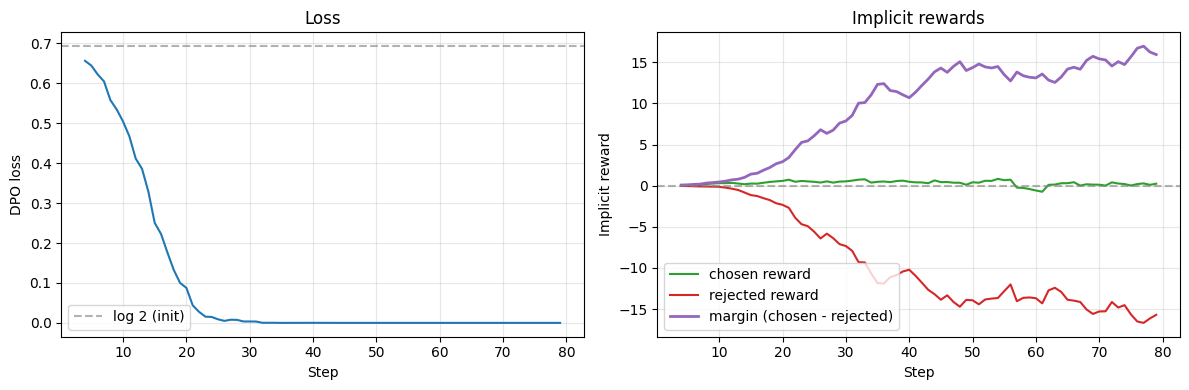

In [13]:
window = 5
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
loss_smooth = pd.Series(dpo_history["loss"]).rolling(window).mean()
ax.plot(loss_smooth, color="tab:blue")
ax.axhline(math.log(2), ls="--", color="gray", alpha=0.6, label="log 2 (init)")
ax.set_xlabel("Step"); ax.set_ylabel("DPO loss"); ax.set_title("Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
margin_smooth = pd.Series(dpo_history["margin"]).rolling(window).mean()
chosen_smooth = pd.Series(dpo_history["chosen_r"]).rolling(window).mean()
reject_smooth = pd.Series(dpo_history["rejected_r"]).rolling(window).mean()
ax.plot(chosen_smooth, label="chosen reward",   color="tab:green")
ax.plot(reject_smooth, label="rejected reward", color="tab:red")
ax.plot(margin_smooth, label="margin (chosen - rejected)", color="tab:purple", lw=2)
ax.axhline(0, ls="--", color="gray", alpha=0.6)
ax.set_xlabel("Step"); ax.set_ylabel("Implicit reward"); ax.set_title("Implicit rewards")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Part 6 — Did it actually learn the preference?

Three evaluations, ordered from cheapest to most concrete:

1. **Held-out preference margin** — does the trained policy assign higher relative probability to *unseen* chosen-rejected pairs than the base does?
2. **Generation comparison** — sample from base vs DPO model on the same prompts and eyeball.
3. **Length distribution** — DPO famously collapses output length (the "length bias" issue). Worth measuring even when it's the *intended* outcome, as it is here.

### 6.1 Held-out preference margin

For each held-out triplet, compute `log p(chosen) − log p(rejected)` under both models. A larger margin under the DPO model is the cleanest signal that the preference generalized.

In [14]:
@torch.no_grad()
def preference_margin(model, val_pairs, use_adapter=True):
    """Mean (log p(chosen) - log p(rejected)) on a held-out set."""
    model.eval()
    margins = []
    ctx = (lambda: None) if use_adapter else model.disable_adapter
    for ex in val_pairs:
        chosen_b   = collate([ex["chosen"]],   tokenizer.pad_token_id)
        rejected_b = collate([ex["rejected"]], tokenizer.pad_token_id)
        if use_adapter:
            cl = model(input_ids=chosen_b["input_ids"],   attention_mask=chosen_b["attention_mask"]).logits
            rl = model(input_ids=rejected_b["input_ids"], attention_mask=rejected_b["attention_mask"]).logits
        else:
            with model.disable_adapter():
                cl = model(input_ids=chosen_b["input_ids"],   attention_mask=chosen_b["attention_mask"]).logits
                rl = model(input_ids=rejected_b["input_ids"], attention_mask=rejected_b["attention_mask"]).logits
        c_lp = sequence_logp(cl, chosen_b["labels"]).item()
        r_lp = sequence_logp(rl, rejected_b["labels"]).item()
        margins.append(c_lp - r_lp)
    return margins


base_margins = preference_margin(dpo_model, val_pairs, use_adapter=False)
dpo_margins  = preference_margin(dpo_model, val_pairs, use_adapter=True)

print(f"Base mean margin (held-out):  {sum(base_margins)/len(base_margins):+.3f}")
print(f"DPO  mean margin (held-out):  {sum(dpo_margins)/len(dpo_margins):+.3f}")
print(f"Per-example win rate (DPO > base): "
      f"{sum(d > b for d, b in zip(dpo_margins, base_margins))} / {len(val_pairs)}")


Base mean margin (held-out):  +54.664
DPO  mean margin (held-out):  +184.094
Per-example win rate (DPO > base): 10 / 10


**Interpreting the numbers.**

- Base margin **near zero or slightly positive**: the base Instruct model has only a weak intrinsic preference between concise and verbose answers — both are fluent.
- DPO margin **clearly positive**: the policy now strongly prefers the chosen (terse) form. That difference is exactly what we trained for.
- Per-example win-rate close to 100% means the preference held on every (or nearly every) unseen example.

### 6.2 Spot-check generations

The numbers above are about *log-probabilities*. The user-facing question is: when we actually *sample* from the model, does it produce terse output?

In [15]:
def generate(model, prompt, max_new_tokens=120, use_adapter=True):
    model.eval()
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True,
    ).to(device)
    if use_adapter:
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
    else:
        with torch.no_grad(), model.disable_adapter():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()


PROBE = [
    "What's the capital of Australia?",
    "How many days are in a leap year?",
    "Who painted The Starry Night?",
    "What does GPU stand for?",
    "Is a tomato a fruit?",
    "What's the largest desert in the world?",
]

for p in PROBE:
    base_out = generate(dpo_model, p, use_adapter=False)
    dpo_out  = generate(dpo_model, p, use_adapter=True)
    print("-" * 80)
    print(f"PROMPT: {p}")
    print(f"BASE:   {base_out}")
    print(f"DPO:    {dpo_out}")
print("-" * 80)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--------------------------------------------------------------------------------
PROMPT: What's the capital of Australia?
BASE:   The capital of Australia is Canberra.
DPO:    Canberra.
--------------------------------------------------------------------------------
PROMPT: How many days are in a leap year?
BASE:   A leap year has 366 days instead of the usual 365 days that make up a common year. This is because every four years, there is an extra day added to the calendar to account for the Earth's slightly faster orbit around the Sun compared to our calendar system.

The rules for determining whether a given year is a leap year are as follows:

1. If the year is evenly divisible by 4, it could be a leap year.
2. However, if the year is also evenly divisible by 100, it is not a leap year unless...
3
DPO:    366
--------------------------------------------------------------------------------
PROMPT: Who painted The Starry Night?
BASE:   Vincent van Gogh is the artist who painted "The S

### 6.3 Length distribution

This is where the famous DPO **length bias** can show up. We *intentionally* trained for shorter responses, so a length collapse is the goal here — but it's worth knowing how dramatic it is, because in tasks where conciseness is *not* the goal, DPO will still tend to shorten outputs as a side effect.

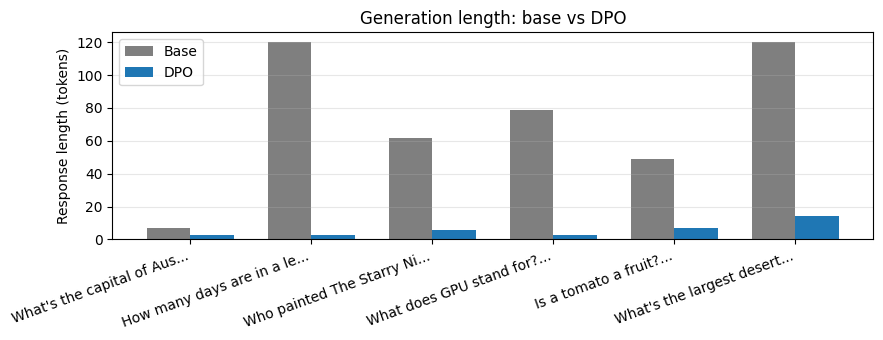

Mean base length: 72.8 tokens
Mean DPO  length: 6.0 tokens


In [16]:
base_lens, dpo_lens = [], []
for p in PROBE:
    base_out = generate(dpo_model, p, use_adapter=False)
    dpo_out  = generate(dpo_model, p, use_adapter=True)
    base_lens.append(len(tokenizer(base_out).input_ids))
    dpo_lens.append(len(tokenizer(dpo_out).input_ids))

import numpy as np
x = np.arange(len(PROBE))
plt.figure(figsize=(9, 3.5))
plt.bar(x - 0.18, base_lens, width=0.36, label="Base", color="tab:gray")
plt.bar(x + 0.18, dpo_lens,  width=0.36, label="DPO",  color="tab:blue")
plt.xticks(x, [p[:25] + "..." for p in PROBE], rotation=20, ha="right")
plt.ylabel("Response length (tokens)")
plt.title("Generation length: base vs DPO")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

print(f"Mean base length: {sum(base_lens)/len(base_lens):.1f} tokens")
print(f"Mean DPO  length: {sum(dpo_lens )/len(dpo_lens ):.1f} tokens")


# References

Rafailov, R., Sharma, A., Mitchell, E., Manning, C. D., Ermon, S., & Finn, C. (2023). Direct preference optimization: Your language model is secretly a reward model. Advances in neural information processing systems, 36, 53728-53741.

Starmer, J. (2025). The StatQuest Illustrated Guide to Neural Networks and AI.

# Tarea en clase

Aplica DPO con LoRA a una **preferencia distinta a la de hoy**, sobre Qwen 2.5 1.5B-Instruct (o el modelo SFT-LoRA que entrenaste en la clase 2).

1. **Define la preferencia.** Data sintética donde existan dos respuestas: una válida y otra no preferida.
2. **Entrena con `β ∈ {0.05, 0.1, 0.5}`** sobre tu dataset, manteniendo `r=8` y el resto de hiperparámetros igual.
4. **Reporta:**
   - Curvas de loss y de margen para los tres valores de `β`.
   - Margen medio held-out y win-rate por ejemplo, para cada `β` y para el base.
   - 3 ejemplos generativos de cada `β` sobre prompts no vistos.
   - Una conclusión: ¿qué `β` funcionó mejor *para tu preferencia*? ¿Por qué crees que es así?